In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("stylematch_dataset.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
  top_color bottom_color top_style bottom_style top_pattern bottom_pattern  \
0     Black         Blue    Casual       Casual       Plain          Plain   
1     White         Blue    Casual       Casual       Plain          Plain   
2       Red        Black    Casual       Casual       Plain          Plain   
3      Blue        White    Casual       Casual       Plain          Plain   
4      Grey        Black    Casual       Casual       Plain          Plain   

   top_formality  bottom_formality color_contrast pattern_match style_match  \
0              2                 2         Medium           Yes         Yes   
1              2                 2           High           Yes         Yes   
2              2                 2           High           Yes         Yes   
3              2                 2           High           Yes         Yes   
4              2                 2            Low           Yes         Yes   

  compatibility  
0        

In [3]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset:
(40, 12)

Column names:
Index(['top_color', 'bottom_color', 'top_style', 'bottom_style', 'top_pattern',
       'bottom_pattern', 'top_formality', 'bottom_formality', 'color_contrast',
       'pattern_match', 'style_match', 'compatibility'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   top_color         40 non-null     str  
 1   bottom_color      40 non-null     str  
 2   top_style         40 non-null     str  
 3   bottom_style      40 non-null     str  
 4   top_pattern       40 non-null     str  
 5   bottom_pattern    40 non-null     str  
 6   top_formality     40 non-null     int64
 7   bottom_formality  40 non-null     int64
 8   color_contrast    40 non-null     str  
 9   pattern_match     40 non-null     str  
 10  style_match       40 non-null     str  
 11  compatibility     

In [4]:
print(df["compatibility"].value_counts())

compatibility
Yes    22
No     18
Name: count, dtype: int64


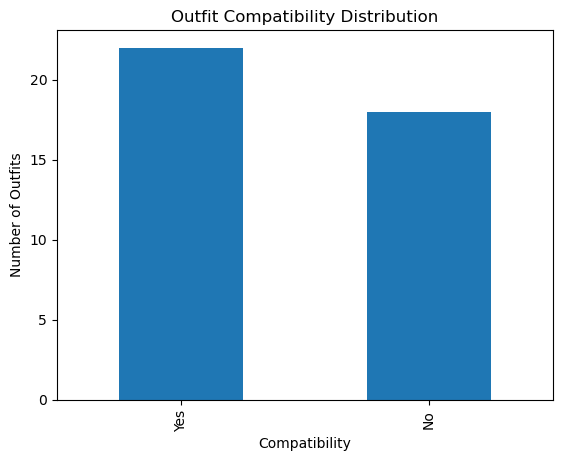

In [5]:
df["compatibility"].value_counts().plot(kind="bar")

plt.title("Outfit Compatibility Distribution")
plt.xlabel("Compatibility")
plt.ylabel("Number of Outfits")
plt.show()

In [6]:
encoder = LabelEncoder()

df_encoded = df.copy()

for column in df_encoded.columns:
    df_encoded[column] = encoder.fit_transform(df_encoded[column].astype(str))

print(df_encoded.head())

   top_color  bottom_color  top_style  bottom_style  top_pattern  \
0          1             2          0             0            0   
1         15             2          0             0            0   
2         13             1          0             0            0   
3          2            11          0             0            0   
4          6             1          0             0            0   

   bottom_pattern  top_formality  bottom_formality  color_contrast  \
0               0              0                 0               2   
1               0              0                 0               0   
2               0              0                 0               0   
3               0              0                 0               0   
4               0              0                 0               1   

   pattern_match  style_match  compatibility  
0              1            1              1  
1              1            1              1  
2              1            1

In [7]:
X = df_encoded.drop("compatibility", axis=1)
y = df_encoded["compatibility"]

print("Features:")
print(X.columns)

print("\nTarget:")
print("compatibility")

Features:
Index(['top_color', 'bottom_color', 'top_style', 'bottom_style', 'top_pattern',
       'bottom_pattern', 'top_formality', 'bottom_formality', 'color_contrast',
       'pattern_match', 'style_match'],
      dtype='str')

Target:
compatibility


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 32
Testing samples: 8


In [9]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [10]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 0 1 1 0 1 0 1]


In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Model Accuracy: 0.875
Accuracy Percentage: 87.5 %


In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3 1]
 [0 4]]


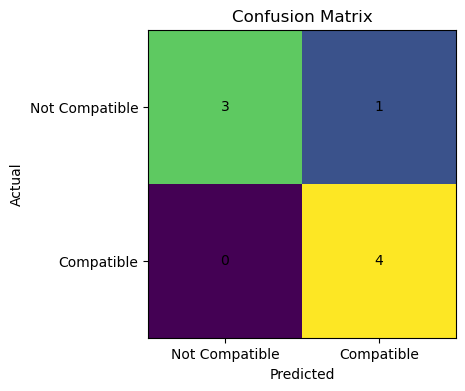

In [14]:
plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Compatible", "Compatible"])
plt.yticks([0, 1], ["Not Compatible", "Compatible"])

for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.show()

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.80      1.00      0.89         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



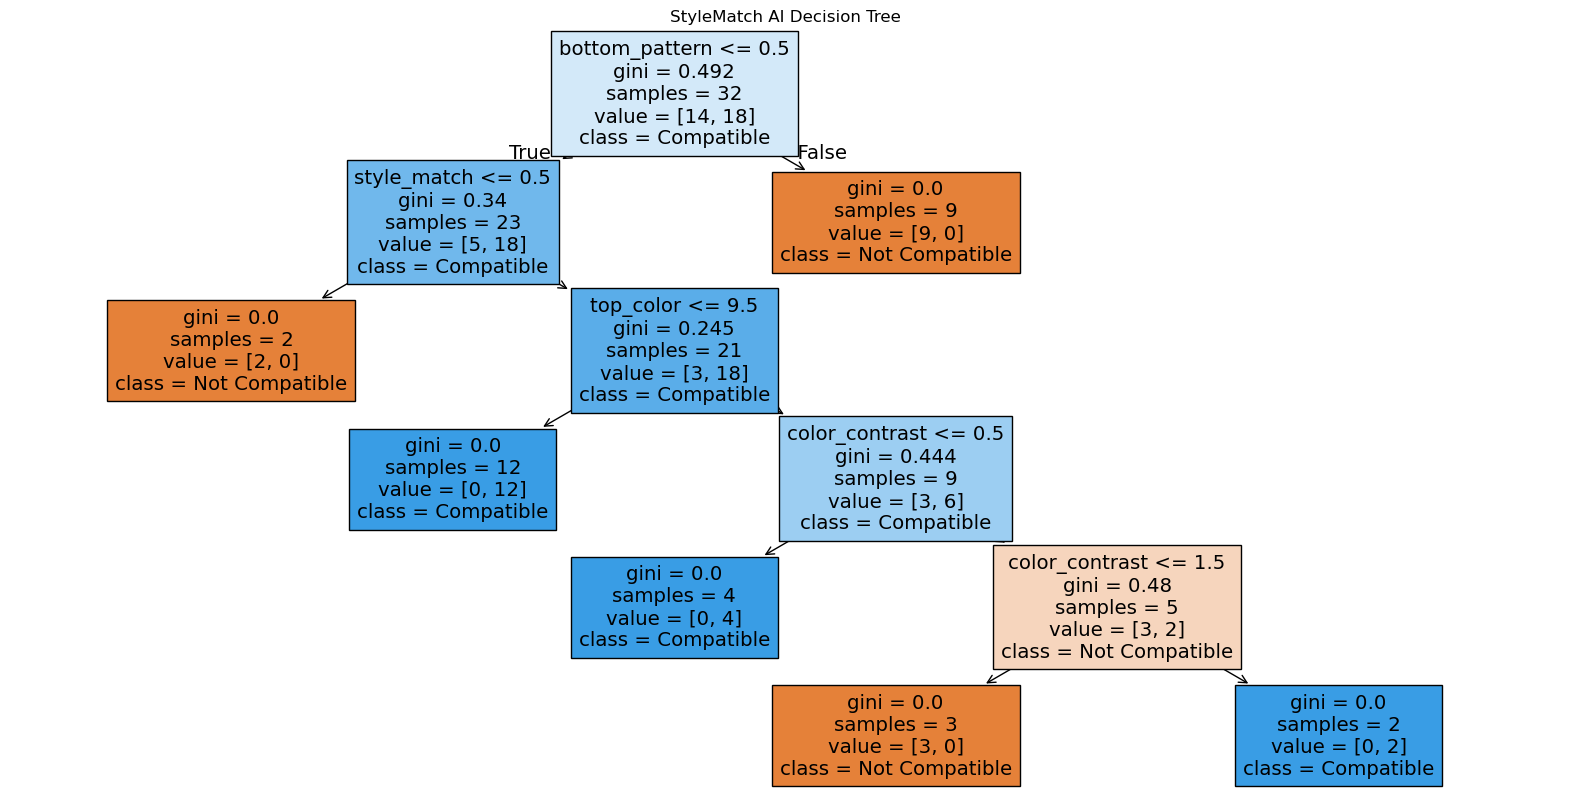

In [16]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Compatible", "Compatible"],
    filled=True
)

plt.title("StyleMatch AI Decision Tree")
plt.show()

In [17]:
def predict_outfit(outfit):
    
    new_outfit = pd.DataFrame([outfit])

    # Encode using the same method
    for column in new_outfit.columns:
        if column in X.columns:
            new_outfit[column] = encoder.fit_transform(
                new_outfit[column].astype(str)
            )

    prediction = model.predict(new_outfit)

    if prediction[0] == 1:
        print("🤖 StyleMatch AI Prediction: ✅ COMPATIBLE")
        print("This outfit is predicted to be a good match.")
    else:
        print("🤖 StyleMatch AI Prediction: ❌ NOT COMPATIBLE")
        print("This outfit is predicted to be a poor match.")

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [19]:
X = df.drop("compatibility", axis=1)
y = df["compatibility"]

categorical_columns = [
    "top_color",
    "bottom_color",
    "top_style",
    "bottom_style",
    "top_pattern",
    "bottom_pattern",
    "color_contrast",
    "pattern_match",
    "style_match"
]

numerical_columns = [
    "top_formality",
    "bottom_formality"
]

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

In [21]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
model.fit(X_train, y_train)

print("StyleMatch AI trained successfully!")

StyleMatch AI trained successfully!


In [24]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 87.5 %


In [25]:
new_outfit = pd.DataFrame({
    "top_color": ["Black"],
    "bottom_color": ["Beige"],
    "top_style": ["Casual"],
    "bottom_style": ["Casual"],
    "top_pattern": ["Plain"],
    "bottom_pattern": ["Plain"],
    "top_formality": [2],
    "bottom_formality": [2],
    "color_contrast": ["Medium"],
    "pattern_match": ["Yes"],
    "style_match": ["Yes"]
})

prediction = model.predict(new_outfit)

if prediction[0] == "Yes":
    print("🤖 StyleMatch AI")
    print("✅ COMPATIBLE OUTFIT")
else:
    print("🤖 StyleMatch AI")
    print("❌ NOT COMPATIBLE")

🤖 StyleMatch AI
✅ COMPATIBLE OUTFIT


In [26]:
top_color = input("Enter top color: ")
bottom_color = input("Enter bottom color: ")

top_style = input("Enter top style (Casual/Formal): ")
bottom_style = input("Enter bottom style (Casual/Formal): ")

top_pattern = input("Enter top pattern (Plain/Printed): ")
bottom_pattern = input("Enter bottom pattern (Plain/Printed): ")

top_formality = int(input("Enter top formality (1-5): "))
bottom_formality = int(input("Enter bottom formality (1-5): "))

color_contrast = input("Enter color contrast (Low/Medium/High): ")
pattern_match = input("Do patterns match? (Yes/No): ")
style_match = input("Do styles match? (Yes/No): ")

Enter top color:  black
Enter bottom color:  black
Enter top style (Casual/Formal):  casual
Enter bottom style (Casual/Formal):  casual
Enter top pattern (Plain/Printed):  printed
Enter bottom pattern (Plain/Printed):  plain
Enter top formality (1-5):  4
Enter bottom formality (1-5):  4
Enter color contrast (Low/Medium/High):  medium
Do patterns match? (Yes/No):  no
Do styles match? (Yes/No):  no


In [27]:
user_outfit = pd.DataFrame({
    "top_color": [top_color],
    "bottom_color": [bottom_color],
    "top_style": [top_style],
    "bottom_style": [bottom_style],
    "top_pattern": [top_pattern],
    "bottom_pattern": [bottom_pattern],
    "top_formality": [top_formality],
    "bottom_formality": [bottom_formality],
    "color_contrast": [color_contrast],
    "pattern_match": [pattern_match],
    "style_match": [style_match]
})

prediction = model.predict(user_outfit)

print("\n" + "="*40)
print("       👕 STYLEMATCH AI")
print("="*40)

if prediction[0] == "Yes":
    print("✅ COMPATIBLE OUTFIT")
    print("The AI predicts that these items work well together.")
else:
    print("❌ NOT COMPATIBLE")
    print("The AI predicts that these items may not work well together.")

print("="*40)


       👕 STYLEMATCH AI
❌ NOT COMPATIBLE
The AI predicts that these items may not work well together.
